CÂU 3.4.1 — Chuẩn hóa min-max 7 tiêu chí (Risk được đảo dấu)
                           Ngành  Tăng trưởng  GDP-share  Lan tỏa  Xuất khẩu  Việc làm  AI readiness  Rủi ro (đảo)
               Nông-Lâm-Thủy sản        0.402      0.424    0.081      0.139     1.000         0.000         1.000
    Công nghiệp chế biến chế tạo        0.974      1.000    0.774      1.000     0.868         0.548         0.351
                        Xây dựng        0.777      0.197    0.194      0.009     0.349         0.068         0.811
                     Khai khoáng        0.000      0.024    0.000      0.028     0.000         0.205         0.000
               Bán buôn - Bán lẻ        0.746      0.329    0.403      0.019     0.581         0.452         0.459
Tài chính - Ngân hàng - Bảo hiểm        0.769      0.107    0.887      0.004     0.019         0.781         0.081
   Logistics - Vận tải - Kho bãi        1.000      0.122    0.677      0.011     0.128         0.370         0.541
 Thông tin - Truyền

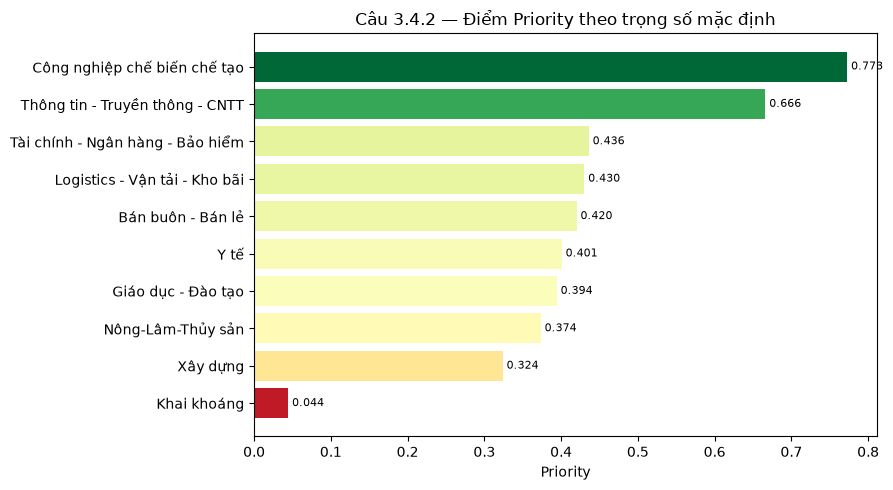


CÂU 3.4.3 — Độ nhạy trọng số a6 (AI readiness) từ 0.05 đến 0.40
Top-3 theo từng mức a6:
  a6                          Hạng 1                          Hạng 2                           Hạng 3
0.05    Công nghiệp chế biến chế tạo Thông tin - Truyền thông - CNTT    Logistics - Vận tải - Kho bãi
0.10    Công nghiệp chế biến chế tạo Thông tin - Truyền thông - CNTT    Logistics - Vận tải - Kho bãi
0.15    Công nghiệp chế biến chế tạo Thông tin - Truyền thông - CNTT    Logistics - Vận tải - Kho bãi
0.20    Công nghiệp chế biến chế tạo Thông tin - Truyền thông - CNTT Tài chính - Ngân hàng - Bảo hiểm
0.25    Công nghiệp chế biến chế tạo Thông tin - Truyền thông - CNTT Tài chính - Ngân hàng - Bảo hiểm
0.30    Công nghiệp chế biến chế tạo Thông tin - Truyền thông - CNTT Tài chính - Ngân hàng - Bảo hiểm
0.35 Thông tin - Truyền thông - CNTT    Công nghiệp chế biến chế tạo Tài chính - Ngân hàng - Bảo hiểm
0.40 Thông tin - Truyền thông - CNTT    Công nghiệp chế biến chế tạo Tài chính - Ngân hàng - Bả

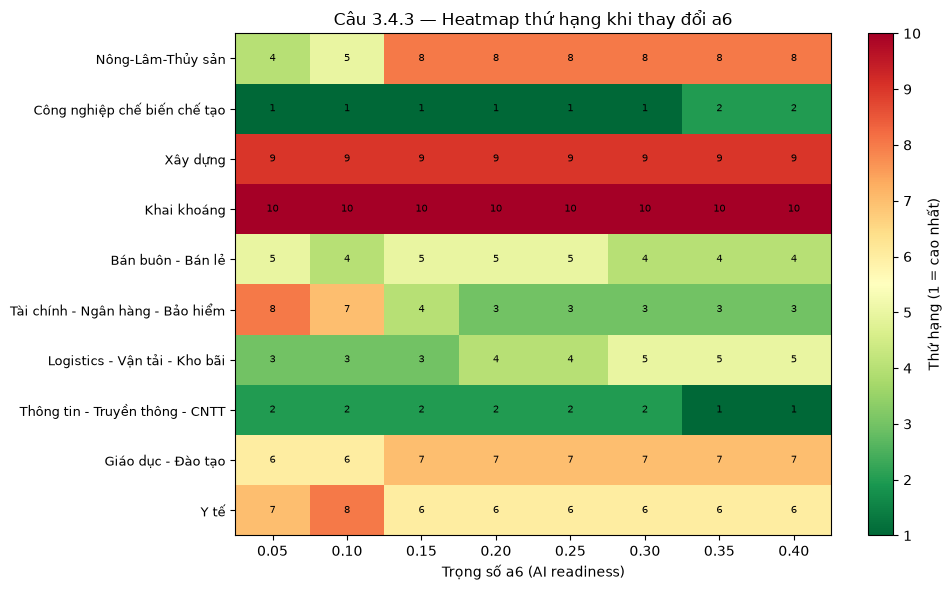


CÂU 3.4.4 — So sánh 'Định hướng tăng trưởng' vs 'Định hướng bao trùm'
 Hạng           Định hướng TĂNG TRƯỞNG             Định hướng BAO TRÙM
    1     Công nghiệp chế biến chế tạo    Công nghiệp chế biến chế tạo
    2  Thông tin - Truyền thông - CNTT Thông tin - Truyền thông - CNTT
    3 Tài chính - Ngân hàng - Bảo hiểm               Nông-Lâm-Thủy sản

Ngành chung trong cả 2 top-3: ['Công nghiệp chế biến chế tạo', 'Thông tin - Truyền thông - CNTT']
Chỉ trong TĂNG TRƯỞNG: ['Tài chính - Ngân hàng - Bảo hiểm']
Chỉ trong BAO TRÙM   : ['Nông-Lâm-Thủy sản']


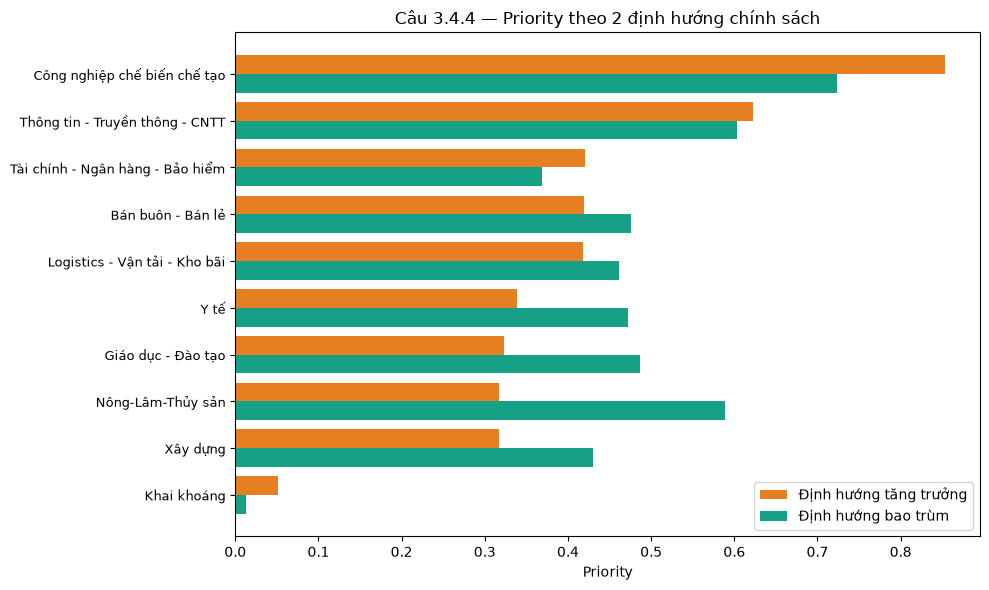


NHẬN XÉT CHÍNH SÁCH (3.4.4):
  • Định hướng TĂNG TRƯỞNG đề cao tăng trưởng/năng suất/xuất khẩu/AI nên
    ưu ái các ngành hiện đại, định hướng xuất khẩu và sẵn sàng công nghệ
    (Công nghiệp chế biến chế tạo, CNTT...).
  • Định hướng BAO TRÙM đề cao việc làm/lan tỏa/giảm rủi ro nên nâng hạng
    các ngành thâm dụng lao động, độ lan tỏa cao và rủi ro tự động hóa thấp
    (Nông-Lâm-Thủy sản, Bán buôn-Bán lẻ...).
  • Điểm chồng lấn (nếu có) là các ngành "cân bằng" — vừa hiệu quả vừa lan tỏa,
    thường là lựa chọn an toàn cho chính sách dù đổi trọng số.

HOÀN TẤT BÀI 3 (Câu 3.4.1 -> 3.4.4)


In [5]:
# =====================================================================
# BÀI 3 - XẾP HẠNG ƯU TIÊN NGÀNH (MULTI-CRITERIA / WEIGHTED SCORING)
# Giải trọn vẹn Câu 3.4.1 -> 3.4.4 trong MỘT cell (Google Colab)
# 7 tiêu chí: tăng trưởng, GDP-share(năng suất), lan tỏa, xuất khẩu,
#             việc làm, AI readiness, và RỦI RO tự động hóa (đảo dấu)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0. ĐỌC DỮ LIỆU
# ---------------------------------------------------------------------
df = pd.read_csv('../data/vietnam_sectors_2024.csv')

# File chỉ có sector_name_en -> bổ sung tên tiếng Việt để báo cáo dễ đọc
vi_map = {
    'Agriculture-Forestry-Fishery': 'Nông-Lâm-Thủy sản',
    'Manufacturing'               : 'Công nghiệp chế biến chế tạo',
    'Construction'                : 'Xây dựng',
    'Mining'                      : 'Khai khoáng',
    'Wholesale-Retail'            : 'Bán buôn - Bán lẻ',
    'Finance-Banking-Insurance'   : 'Tài chính - Ngân hàng - Bảo hiểm',
    'Logistics-Transport-Warehousing': 'Logistics - Vận tải - Kho bãi',
    'Information-Communication-IT': 'Thông tin - Truyền thông - CNTT',
    'Education-Training'          : 'Giáo dục - Đào tạo',
    'Healthcare'                  : 'Y tế',
}
df['sector_name_vi'] = df['sector_name_en'].map(vi_map)

# ---------------------------------------------------------------------
# Định nghĩa 7 tiêu chí (6 "tốt" càng cao càng tốt + 1 "xấu" = Risk)
#   a1 tăng trưởng | a2 GDP-share(năng suất) | a3 lan tỏa | a4 xuất khẩu
#   a5 việc làm    | a6 AI readiness         | a7 RỦI RO (đảo dấu)
# ---------------------------------------------------------------------
cols_good = ['growth_rate_2024_pct',  # a1 tăng trưởng
             'gdp_share_2024_pct',    # a2 đại diện năng suất/quy mô
             'spillover_coef_0_1',    # a3 lan tỏa
             'export_billion_USD',    # a4 xuất khẩu
             'labor_million',         # a5 việc làm
             'ai_readiness_0_100']    # a6 AI readiness
col_bad   = 'automation_risk_pct'     # a7 rủi ro tự động hóa (đảo dấu)

crit_labels = ['Tăng trưởng', 'GDP-share', 'Lan tỏa', 'Xuất khẩu',
               'Việc làm', 'AI readiness', 'Rủi ro (đảo)']

# =====================================================================
# CÂU 3.4.1 — CHUẨN HÓA MIN-MAX CẢ 7 CỘT (ĐẢO DẤU RISK)
# =====================================================================
print("="*78)
print("CÂU 3.4.1 — Chuẩn hóa min-max 7 tiêu chí (Risk được đảo dấu)")
print("="*78)

def norm_good(x):  # benefit: càng cao càng tốt
    return (x - x.min()) / (x.max() - x.min())
def norm_bad(x):   # cost: đảo dấu -> rủi ro thấp = điểm cao
    return (x.max() - x) / (x.max() - x.min())

Xg = df[cols_good].apply(norm_good)      # 6 cột tốt
Xb = norm_bad(df[col_bad])               # cột rủi ro đã đảo

# Ma trận chuẩn hóa đầy đủ 7 cột
Xnorm = Xg.copy()
Xnorm['risk_inv'] = Xb.values
Xnorm.columns = crit_labels
norm_view = Xnorm.copy()
norm_view.insert(0, 'Ngành', df['sector_name_vi'].values)
pd.options.display.float_format = '{:.3f}'.format
print(norm_view.to_string(index=False))

# Ma trận numeric 7 cột để nhân trọng số
X7 = Xnorm.values   # shape (10, 7)

# =====================================================================
# CÂU 3.4.2 — PRIORITY VỚI BỘ TRỌNG SỐ MẶC ĐỊNH + XẾP HẠNG
# =====================================================================
print("\n" + "="*78)
print("CÂU 3.4.2 — Priority với trọng số mặc định & xếp hạng giảm dần")
print("="*78)

# Trọng số đề bài: a1..a7
w_default_raw = np.array([0.15, 0.15, 0.20, 0.15, 0.10, 0.20, 0.15])
print(f"Tổng trọng số gốc a1..a7 = {w_default_raw.sum():.2f}  "
      f"-> chuẩn hóa lại để tổng = 1 (đảm bảo Priority ∈ [0,1]).")
w_default = w_default_raw / w_default_raw.sum()

df['Priority'] = X7 @ w_default
rank_df = (df[['sector_name_vi', 'Priority']]
           .sort_values('Priority', ascending=False)
           .reset_index(drop=True))
rank_df.index += 1
rank_df.columns = ['Ngành', 'Priority']
print("\nXẾP HẠNG (Priority giảm dần):")
print(rank_df.to_string())

top3_default = rank_df['Ngành'].head(3).tolist()
print(f"\n>>> TOP-3 mặc định: {top3_default}")

# Biểu đồ cột xếp hạng
plt.figure(figsize=(9, 5))
order = rank_df.sort_values('Priority')
colors = plt.cm.RdYlGn(order['Priority'] / order['Priority'].max())
plt.barh(order['Ngành'], order['Priority'], color=colors)
for y, v in enumerate(order['Priority']):
    plt.text(v + 0.005, y, f'{v:.3f}', va='center', fontsize=8)
plt.title('Câu 3.4.2 — Điểm Priority theo trọng số mặc định', fontsize=12)
plt.xlabel('Priority'); plt.tight_layout(); plt.show()

# =====================================================================
# CÂU 3.4.3 — ĐỘ NHẠY THEO a6 (AI READINESS): 0.05 -> 0.40, bước 0.05
#   Khi đổi a6, GIỮ tỷ lệ các trọng số còn lại rồi chuẩn hóa tổng = 1
# =====================================================================
print("\n" + "="*78)
print("CÂU 3.4.3 — Độ nhạy trọng số a6 (AI readiness) từ 0.05 đến 0.40")
print("="*78)

a6_values = np.arange(0.05, 0.40 + 1e-9, 0.05)   # 0.05,...,0.40
idx_a6 = 5                                        # vị trí AI readiness trong 7 cột

# Trọng số "nền" của 6 tiêu chí còn lại (giữ nguyên tỷ lệ tương đối)
base_other = np.delete(w_default_raw, idx_a6)
base_other = base_other / base_other.sum()        # chuẩn hóa trong nhóm còn lại

sectors = df['sector_name_vi'].values
rank_matrix = np.zeros((len(a6_values), len(sectors)), dtype=int)  # hạng (1=cao nhất)
top3_track = []

for r, a6 in enumerate(a6_values):
    w = np.zeros(7)
    w[idx_a6] = a6
    rest = 1.0 - a6
    w_rest = base_other * rest
    j = 0
    for k in range(7):
        if k != idx_a6:
            w[k] = w_rest[j]; j += 1
    scores = X7 @ w
    ranking = (-scores).argsort().argsort() + 1   # hạng 1 = điểm cao nhất
    rank_matrix[r] = ranking
    top3 = [sectors[i] for i in np.argsort(-scores)[:3]]
    top3_track.append(top3)

# In top-3 theo từng giá trị a6
print("Top-3 theo từng mức a6:")
sens_tab = pd.DataFrame({
    'a6': [f'{v:.2f}' for v in a6_values],
    'Hạng 1': [t[0] for t in top3_track],
    'Hạng 2': [t[1] for t in top3_track],
    'Hạng 3': [t[2] for t in top3_track],
})
print(sens_tab.to_string(index=False))

changed = len({tuple(t) for t in top3_track}) > 1
print(f"\n>>> TOP-3 CÓ thay đổi khi a6 biến thiên? {'CÓ' if changed else 'KHÔNG'}")
if changed:
    print("    (Một số ngành mạnh về AI readiness, vd ICT/Tài chính, leo hạng khi a6 tăng.)")
else:
    print("    (Top-3 ổn định — kết quả bền vững với trọng số AI readiness.)")

# Heatmap hạng (hàng = ngành, cột = a6); màu sáng = hạng cao
plt.figure(figsize=(10, 6))
hm = rank_matrix.T   # shape (sector, a6)
im = plt.imshow(hm, aspect='auto', cmap='RdYlGn_r')
plt.colorbar(im, label='Thứ hạng (1 = cao nhất)')
plt.yticks(range(len(sectors)), sectors, fontsize=9)
plt.xticks(range(len(a6_values)), [f'{v:.2f}' for v in a6_values])
plt.xlabel('Trọng số a6 (AI readiness)')
plt.title('Câu 3.4.3 — Heatmap thứ hạng khi thay đổi a6', fontsize=12)
for i in range(hm.shape[0]):
    for jcol in range(hm.shape[1]):
        plt.text(jcol, i, hm[i, jcol], ha='center', va='center', fontsize=7,
                 color='black')
plt.tight_layout(); plt.show()

# =====================================================================
# CÂU 3.4.4 — SO SÁNH 2 BỘ TRỌNG SỐ: "TĂNG TRƯỞNG" vs "BAO TRÙM"
# =====================================================================
print("\n" + "="*78)
print("CÂU 3.4.4 — So sánh 'Định hướng tăng trưởng' vs 'Định hướng bao trùm'")
print("="*78)

# Thứ tự 7 cột: [Tăng trưởng, GDP-share, Lan tỏa, Xuất khẩu, Việc làm, AI, Rủi ro-đảo]
# Bộ A - ĐỊNH HƯỚNG TĂNG TRƯỞNG: ưu tiên tăng trưởng, năng suất(GDP-share), xuất khẩu, AI
w_growth = np.array([0.25, 0.20, 0.05, 0.20, 0.05, 0.20, 0.05])
# Bộ B - ĐỊNH HƯỚNG BAO TRÙM: ưu tiên việc làm, lan tỏa, giảm rủi ro
w_inclusive = np.array([0.10, 0.05, 0.25, 0.05, 0.25, 0.05, 0.25])

w_growth   = w_growth / w_growth.sum()
w_inclusive = w_inclusive / w_inclusive.sum()

df['P_growth']    = X7 @ w_growth
df['P_inclusive'] = X7 @ w_inclusive

rank_g = df.sort_values('P_growth', ascending=False)['sector_name_vi'].head(3).tolist()
rank_i = df.sort_values('P_inclusive', ascending=False)['sector_name_vi'].head(3).tolist()

comp = pd.DataFrame({
    'Hạng': [1, 2, 3],
    'Định hướng TĂNG TRƯỞNG': rank_g,
    'Định hướng BAO TRÙM'   : rank_i,
})
print(comp.to_string(index=False))

set_g, set_i = set(rank_g), set(rank_i)
print(f"\nNgành chung trong cả 2 top-3: {sorted(set_g & set_i) or 'không có'}")
print(f"Chỉ trong TĂNG TRƯỞNG: {sorted(set_g - set_i) or 'không có'}")
print(f"Chỉ trong BAO TRÙM   : {sorted(set_i - set_g) or 'không có'}")

# Biểu đồ so sánh điểm theo 2 bộ trọng số
comp_full = df[['sector_name_vi', 'P_growth', 'P_inclusive']].copy()
comp_full = comp_full.sort_values('P_growth', ascending=True)
ypos = np.arange(len(comp_full)); h = 0.4
plt.figure(figsize=(10, 6))
plt.barh(ypos + h/2, comp_full['P_growth'], h, label='Định hướng tăng trưởng', color='#e67e22')
plt.barh(ypos - h/2, comp_full['P_inclusive'], h, label='Định hướng bao trùm', color='#16a085')
plt.yticks(ypos, comp_full['sector_name_vi'], fontsize=9)
plt.xlabel('Priority'); plt.legend()
plt.title('Câu 3.4.4 — Priority theo 2 định hướng chính sách', fontsize=12)
plt.tight_layout(); plt.show()

print(f"""
NHẬN XÉT CHÍNH SÁCH (3.4.4):
  • Định hướng TĂNG TRƯỞNG đề cao tăng trưởng/năng suất/xuất khẩu/AI nên
    ưu ái các ngành hiện đại, định hướng xuất khẩu và sẵn sàng công nghệ
    (Công nghiệp chế biến chế tạo, CNTT...).
  • Định hướng BAO TRÙM đề cao việc làm/lan tỏa/giảm rủi ro nên nâng hạng
    các ngành thâm dụng lao động, độ lan tỏa cao và rủi ro tự động hóa thấp
    (Nông-Lâm-Thủy sản, Bán buôn-Bán lẻ...).
  • Điểm chồng lấn (nếu có) là các ngành "cân bằng" — vừa hiệu quả vừa lan tỏa,
    thường là lựa chọn an toàn cho chính sách dù đổi trọng số.
""")

print("="*78)
print("HOÀN TẤT BÀI 3 (Câu 3.4.1 -> 3.4.4)")
print("="*78)